In [38]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd
import re

In [40]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Data/Windows_2k.log"

# Open the raw log file and read the lines
print("\nLoading log file")
with open(file_path,"r") as file:
  raw_logs = file.readlines()

# Let's see how many logs we have and look at the first one
print(f"Total log entries successfully loaded: {len(raw_logs)}\n")
print(f"Raw log example: \n {raw_logs[0]}")


Loading log file
Total log entries successfully loaded: 2000

Raw log example: 
 2016-09-28 04:30:30, Info                  CBS    Loaded Servicing Stack v6.1.7601.23505 with Core: C:\Windows\winsxs\amd64_microsoft-windows-servicingstack_31bf3856ad364e35_6.1.7601.23505_none_681aa442f6fed7f0\cbscore.dll



In [41]:
log_pattern = re.compile(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}), (\w+)\s+([\w\-]+)\s+(.*)')
parsed_logs = []

for line in raw_logs:
    match = log_pattern.match(line)
    if match:
        parsed_logs.append(match.groups())

df_logs = pd.DataFrame(parsed_logs, columns=['Timestamp', 'LogLevel', 'Component', 'Message'])
df_logs['Timestamp'] = pd.to_datetime(df_logs['Timestamp'])

print(f"Successfully parsed {len(df_logs)} log entries.")
display(df_logs.head())

Successfully parsed 2000 log entries.


,Timestamp,LogLevel,Component,Message
0,2016-09-28 04:30:30,Info,CBS,Loaded Servicing Stack v6.1.7601.23505 with Co...
1,2016-09-28 04:30:31,Info,CSI,00000001@2016/9/27:20:30:31.455 WcpInitialize ...
2,2016-09-28 04:30:31,Info,CSI,00000002@2016/9/27:20:30:31.458 WcpInitialize ...
3,2016-09-28 04:30:31,Info,CSI,00000003@2016/9/27:20:30:31.458 WcpInitialize ...
4,2016-09-28 04:30:31,Info,CBS,Ending TrustedInstaller initialization.


In [42]:
df_logs["Message"][0]

'Loaded Servicing Stack v6.1.7601.23505 with Core: C:\\Windows\\winsxs\\amd64_microsoft-windows-servicingstack_31bf3856ad364e35_6.1.7601.23505_none_681aa442f6fed7f0\\cbscore.dll'

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Clean_Log'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

tfidf_df.head()

,all,and,applicability,applicablestate,applyflags,are,as,attribute,autostart,backup,...,upload,version,warning,was,wcpdll,wcpinitialize,windows,windowsupdateagent,with,writeable
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.358976,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.423829,0.0,0.0,0.423829,0.423829,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.423829,0.0,0.0,0.423829,0.423829,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.423829,0.0,0.0,0.423829,0.423829,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0


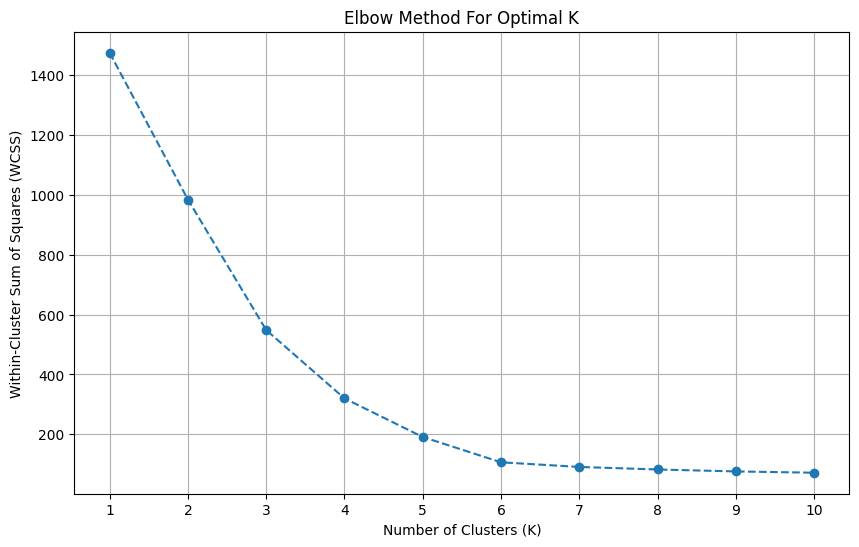

In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Let's test K values from 1 to 10
K_range = range(1, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [45]:
from sklearn.cluster import KMeans

k = 4 # Based on the elbow method, assuming 4 is chosen as optimal K

# Initialize KMeans model with the chosen k
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit the model to the TF-IDF matrix and get cluster labels
df['Cluster'] = kmeans_model.fit_predict(tfidf_matrix)

print(f"K-Means clustering performed with {k} clusters.")
print("Distribution of logs per cluster:")
display(df['Cluster'].value_counts().sort_index().to_frame())

K-Means clustering performed with 4 clusters.
Distribution of logs per cluster:


,count
Cluster,
0,558
1,609
2,553
3,280


In [46]:
df.head()

,Raw_Log,Clean_Log,Cluster
0,"2016-09-28 04:30:30, Info CBS...",info cbs loaded servicing ...,2
1,"2016-09-28 04:30:31, Info CSI...",info csi wcpinitialize wc...,2
2,"2016-09-28 04:30:31, Info CSI...",info csi wcpinitialize wc...,2
3,"2016-09-28 04:30:31, Info CSI...",info csi wcpinitialize wc...,2
4,"2016-09-28 04:30:31, Info CBS...",info cbs ending trustedins...,2


In [47]:
print("Top terms per cluster:")
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()

for i in range(4):
    print(f"Cluster {i}:")
    for ind in order_centroids[i, :10]: # Print top 10 terms per cluster
        print(f' {terms[ind]}', end='')
    print('\n')

Top terms per cluster:
Cluster 0:
 package read out currentstate applicability applicablestate cached for packageforkbbfadeamd cbs

Cluster 1:
 session by windowsupdateagent client initialized cbs info spp warning upload

Cluster 2:
 hresult cbsemanifestinvaliditem expecting name to failed element next get attribute

Cluster 3:
 unrecognized packageextended warning attribute cbs info windows was wcpdll upload



In [48]:
for i in range(4):
    print(f"\n--- Sample logs from Cluster {i} ---")
    cluster_logs = df[df['Cluster'] == i]['Raw_Log'].head(5).tolist()
    for j, log in enumerate(cluster_logs):
        print(f"Log {j+1}: {log.strip()}")


--- Sample logs from Cluster 0 ---
Log 1: 2016-09-28 04:30:33, Info                  CBS    Read out cached package applicability for package: Package_for_KB3121255~31bf3856ad364e35~amd64~~6.1.1.0, ApplicableState: 112, CurrentState:112
Log 2: 2016-09-28 04:30:33, Info                  CBS    Read out cached package applicability for package: Package_for_KB2656356~31bf3856ad364e35~amd64~~6.1.1.1, ApplicableState: 80, CurrentState:112
Log 3: 2016-09-28 04:30:33, Info                  CBS    Read out cached package applicability for package: Package_for_KB3108664~31bf3856ad364e35~amd64~~6.1.1.0, ApplicableState: 112, CurrentState:112
Log 4: 2016-09-28 04:30:33, Info                  CBS    Read out cached package applicability for package: Package_for_KB3115858~31bf3856ad364e35~amd64~~6.1.1.0, ApplicableState: 80, CurrentState:112
Log 5: 2016-09-28 04:30:34, Info                  CBS    Read out cached package applicability for package: Package_for_KB3127220~31bf3856ad364e35~amd64~~6.1.

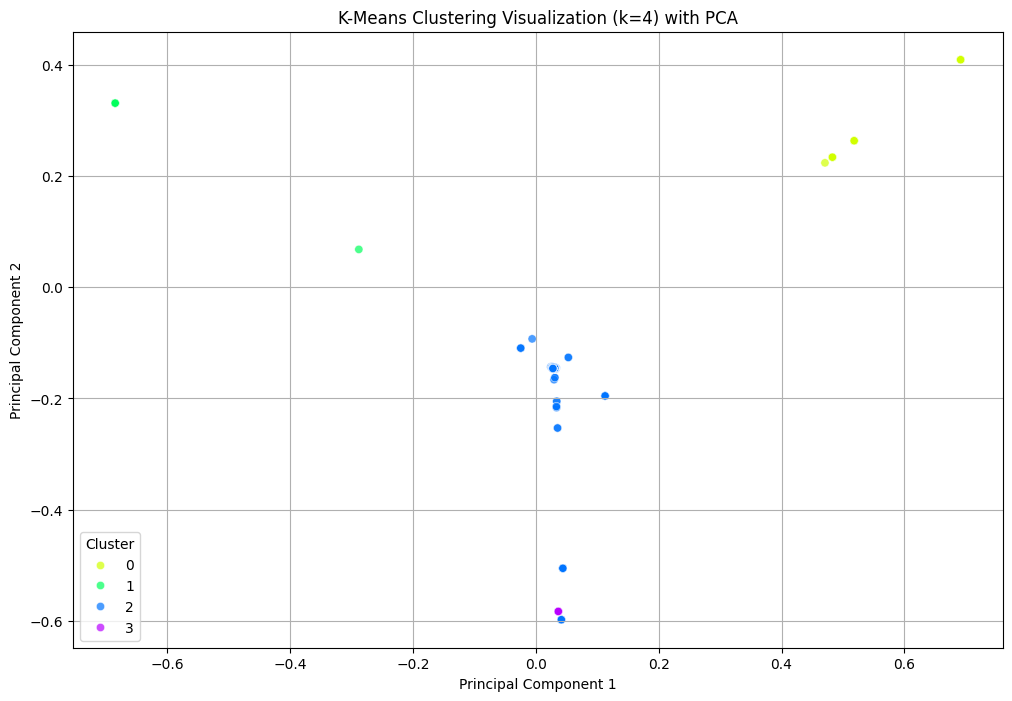

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

k = 4 # The number of clusters decided earlier

pca = PCA(n_components=2)
principal_components = pca.fit_transform(tfidf_matrix)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette=sns.color_palette('hsv', k),
    legend='full',
    alpha=0.7
)
plt.title(f'K-Means Clustering Visualization (k={k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Let's test K values from 1 to 10
K_range = range(1, 100)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (70) found smaller than n_clusters (71). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (70) found smaller than n_clusters (72). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (70) found smaller than n_clusters (73). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (70) found smaller than n_clusters (74). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/